In [1]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

stocks = pd.read_csv("historical_stocks.csv")
prices = pd.read_csv("historical_stock_prices.csv")

stocks.head()
prices.head()

Saving Daily Historical Stock Prices (1970 - 2018).zip to Daily Historical Stock Prices (1970 - 2018).zip


FileNotFoundError: [Errno 2] No such file or directory: 'historical_stocks.csv'

In [2]:
import zipfile

zip_path = "Daily Historical Stock Prices (1970 - 2018).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

In [3]:
import os

print(os.listdir())

['.config', 'historical_stock_prices.csv', 'Daily Historical Stock Prices (1970 - 2018).zip', 'historical_stocks.csv', 'sample_data']


In [4]:
import pandas as pd

stocks = pd.read_csv("historical_stocks.csv")
prices = pd.read_csv("historical_stock_prices.csv")

stocks.head()
prices.head()

,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14


In [5]:
# Convert date column
prices['date'] = pd.to_datetime(prices['date'])

# Set as index
prices.set_index('date', inplace=True)

# Create decade column
prices['decade'] = (prices.index.year // 10) * 10

prices.head()

,ticker,open,close,adj_close,low,high,volume,decade
date,,,,,,,,
2013-05-08,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2010
2013-05-09,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2010
2013-05-10,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2010
2013-05-13,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2010
2013-05-14,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2010


In [6]:
decades = {}

for decade in prices['decade'].unique():
    decades[decade] = prices[prices['decade'] == decade]

# Check one decade
decades[list(decades.keys())[0]].head()

,ticker,open,close,adj_close,low,high,volume,decade
date,,,,,,,,
2013-05-08,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2010
2013-05-09,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2010
2013-05-10,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2010
2013-05-13,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2010
2013-05-14,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2010


In [7]:
# Check column names first
print(stocks.columns)

Index(['ticker', 'exchange', 'name', 'sector', 'industry'], dtype='object')


In [8]:
df = prices.merge(stocks, on='ticker', how='left')

df.head()

,ticker,open,close,adj_close,low,high,volume,decade,exchange,name,sector,industry
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE


In [9]:
summary_stats = {}

for decade, data in decades.items():
    stats = data[['open','high','low','close','volume']].describe()
    summary_stats[decade] = stats

    print(f"\n===== {decade}s =====")
    print(stats)


===== 2010s =====
               open          high           low         close        volume
count  9.338934e+06  9.338934e+06  9.338934e+06  9.338934e+06  9.338934e+06
mean   6.526110e+01  6.672395e+01  6.391735e+01  6.527833e+01  1.320505e+06
std    1.820182e+03  1.941571e+03  1.763144e+03  1.850128e+03  1.770789e+07
min    4.000000e-04  4.000000e-04  3.000000e-04  3.000000e-04  1.000000e+00
25%    1.032000e+01  1.049000e+01  1.015000e+01  1.032000e+01  3.350000e+04
50%    2.001000e+01  2.028500e+01  1.975000e+01  2.001000e+01  1.654000e+05
75%    3.826000e+01  3.874000e+01  3.778000e+01  3.826500e+01  7.144000e+05
max    1.375000e+06  1.542500e+06  1.300000e+06  1.347500e+06  4.483504e+09

===== 2000s =====
               open          high           low         close        volume
count  6.572053e+06  6.572053e+06  6.572053e+06  6.572053e+06  6.572053e+06
mean   1.222958e+02  1.256463e+02  1.191707e+02  1.224408e+02  1.383562e+06
std    4.485636e+03  4.703969e+03  4.318822e+03  4

/tmp/ipykernel_1851/3883335722.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = data['close'].resample('M').mean()


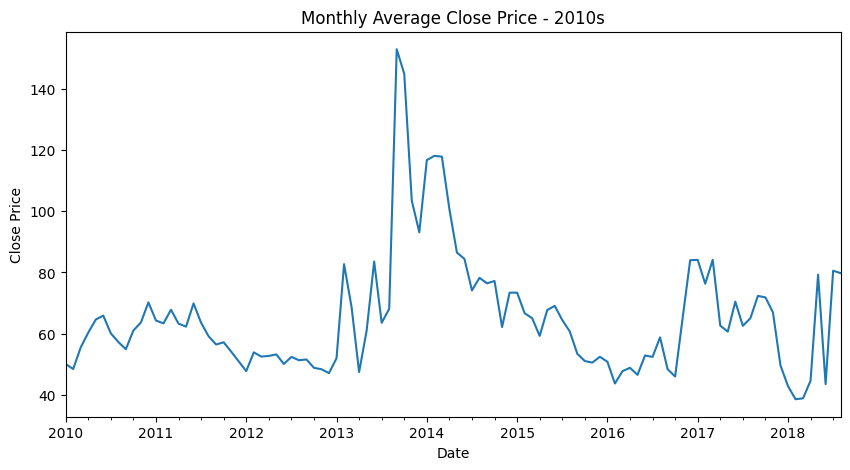

/tmp/ipykernel_1851/3883335722.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = data['close'].resample('M').mean()


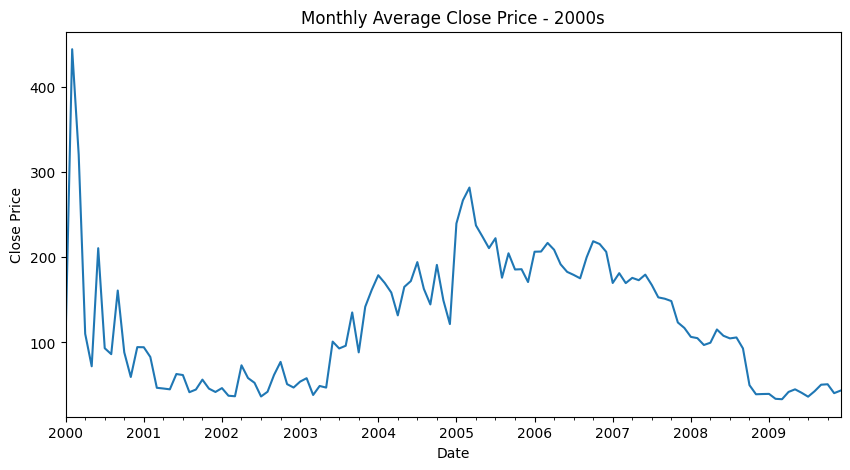

/tmp/ipykernel_1851/3883335722.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = data['close'].resample('M').mean()


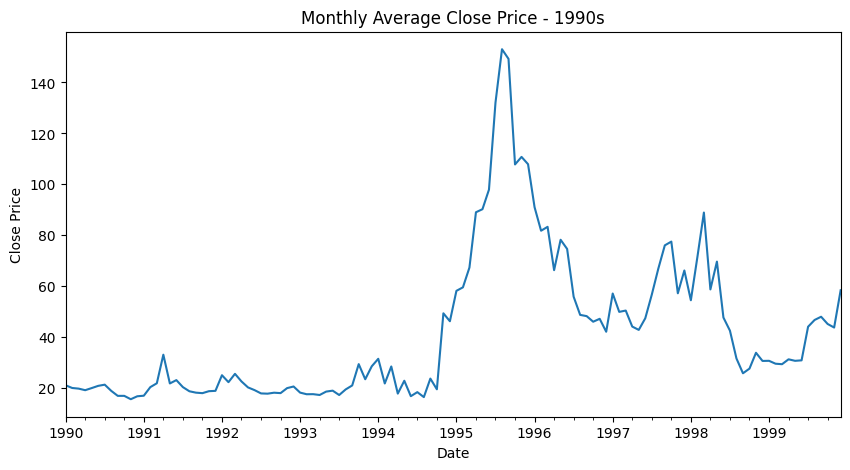

/tmp/ipykernel_1851/3883335722.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = data['close'].resample('M').mean()


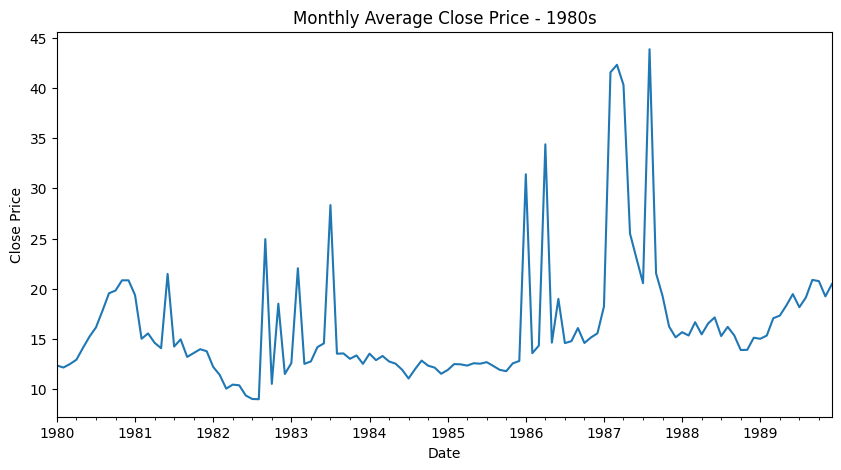

/tmp/ipykernel_1851/3883335722.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = data['close'].resample('M').mean()


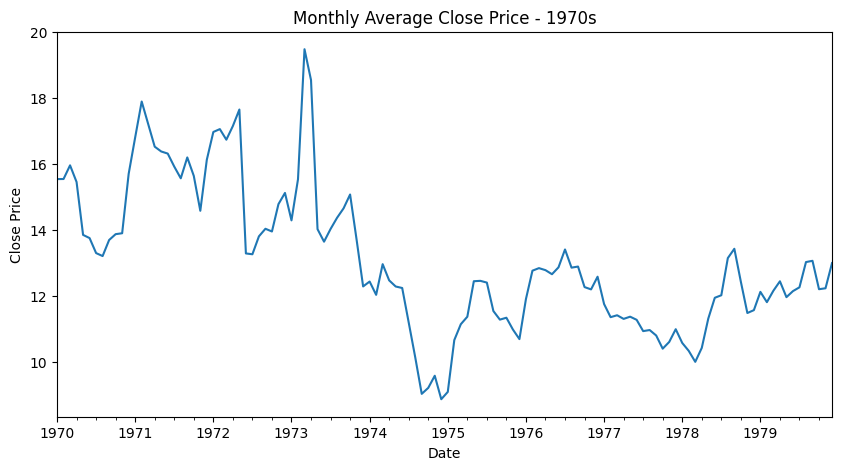

In [10]:
import matplotlib.pyplot as plt

for decade, data in decades.items():
    monthly_close = data['close'].resample('M').mean()

    plt.figure(figsize=(10,5))
    monthly_close.plot()
    plt.title(f"Monthly Average Close Price - {decade}s")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.show()

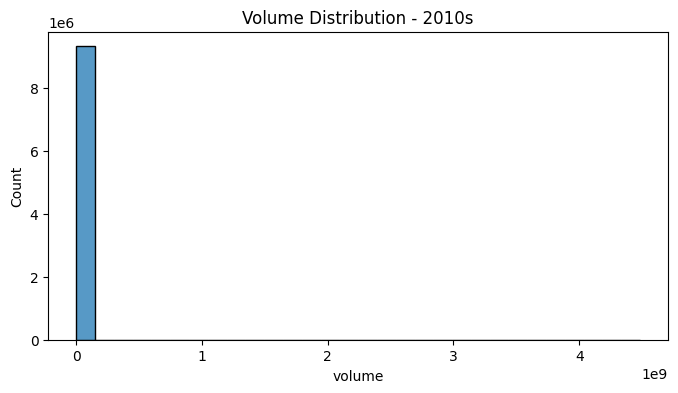

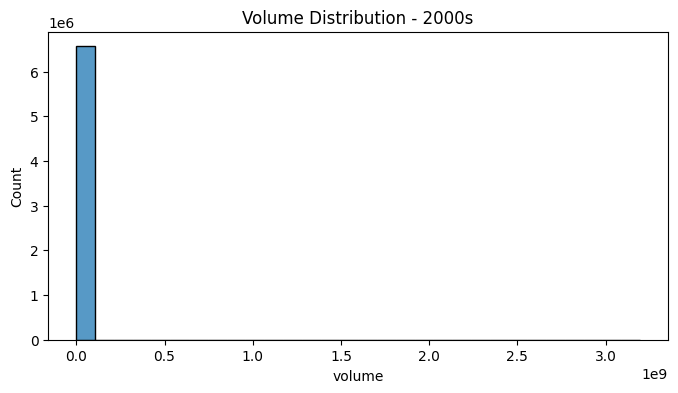

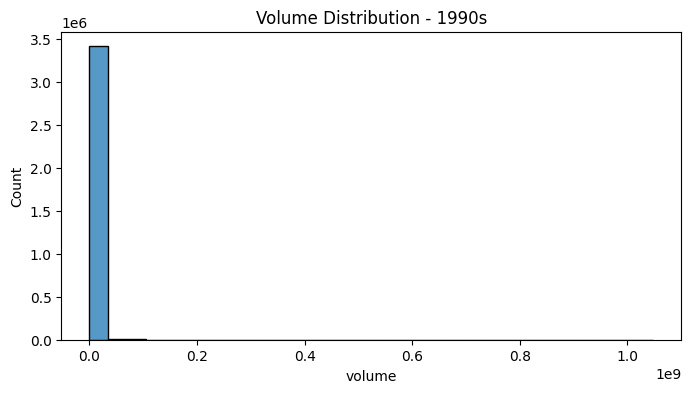

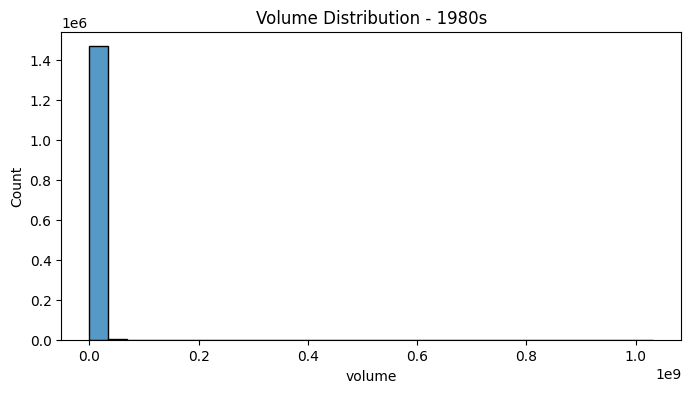

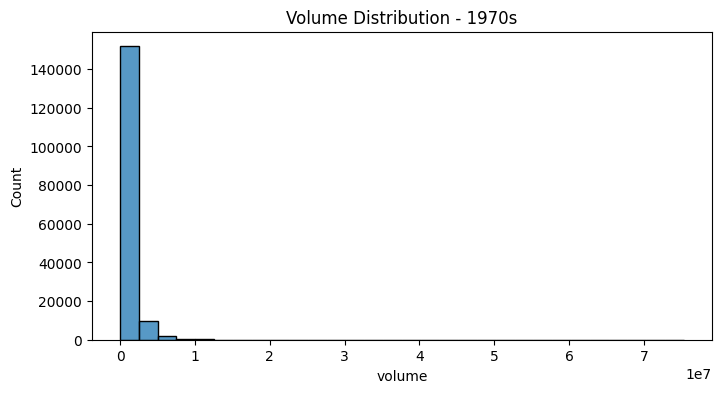

In [11]:
import seaborn as sns

for decade, data in decades.items():
    plt.figure(figsize=(8,4))
    sns.histplot(data['volume'], bins=30)
    plt.title(f"Volume Distribution - {decade}s")
    plt.show()

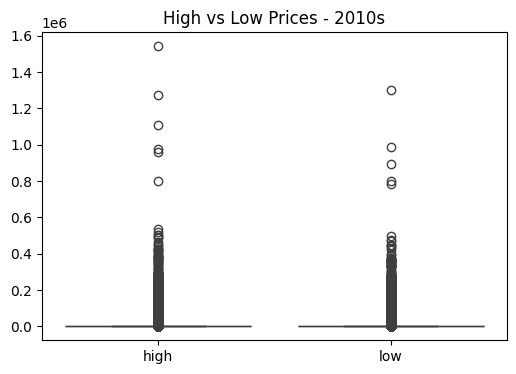

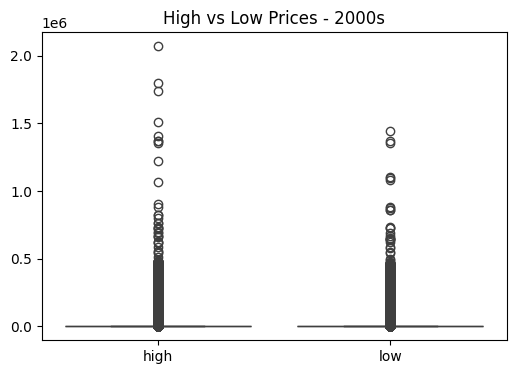

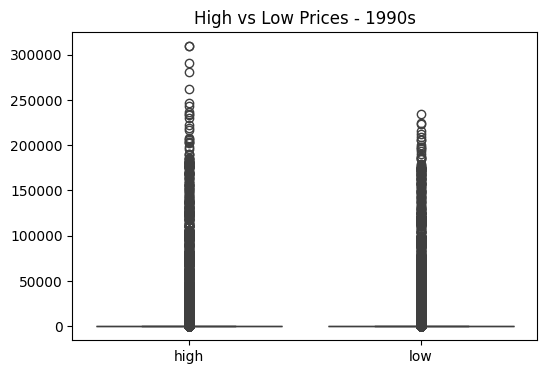

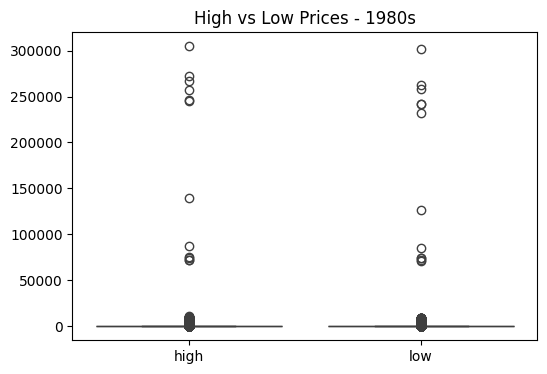

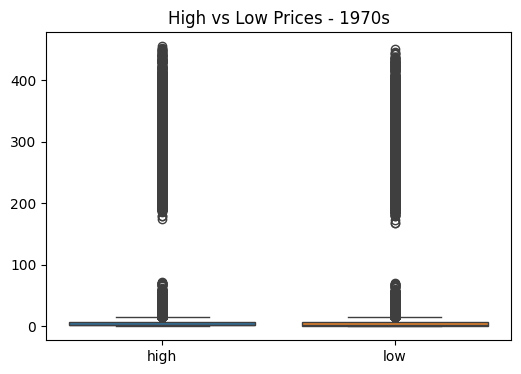

In [12]:
for decade, data in decades.items():
    plt.figure(figsize=(6,4))
    sns.boxplot(data=data[['high','low']])
    plt.title(f"High vs Low Prices - {decade}s")
    plt.show()

In [13]:
data_sample = data.sample(50000)

In [14]:
for decade in summary_stats:
    print(f"\n--- {decade}s Summary ---")
    print(summary_stats[decade].loc[['mean','std']])


--- 2010s Summary ---
             open         high          low        close        volume
mean    65.261101    66.723946    63.917347    65.278332  1.320505e+06
std   1820.181589  1941.571402  1763.144292  1850.127729  1.770789e+07

--- 2000s Summary ---
             open         high          low        close        volume
mean   122.295850   125.646271   119.170676   122.440812  1.383562e+06
std   4485.636333  4703.968766  4318.821828  4509.781698  9.230143e+06

--- 1990s Summary ---
             open         high          low        close        volume
mean    45.291459    46.871896    43.814977    45.303495  8.635272e+05
std   1391.110191  1464.629619  1329.334616  1391.576526  5.834012e+06

--- 1980s Summary ---
            open        high         low       close        volume
mean   16.814261   17.095074   16.561523   16.824845  8.375234e+05
std   573.048093  582.814179  562.257404  575.029287  4.510088e+06

--- 1970s Summary ---
           open       high        low      cl

In [15]:
print("Key Insights:")
print("1. Stock prices generally increase over decades.")
print("2. Trading volume grows significantly in recent decades.")
print("3. Presence of outliers suggests market volatility.")

Key Insights:
1. Stock prices generally increase over decades.
2. Trading volume grows significantly in recent decades.
3. Presence of outliers suggests market volatility.


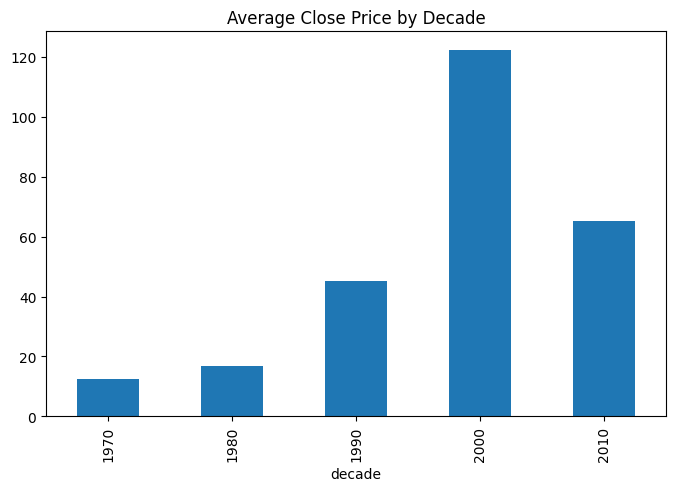

In [16]:
avg_close_by_decade = prices.groupby('decade')['close'].mean()

avg_close_by_decade.plot(kind='bar', figsize=(8,5))
plt.title("Average Close Price by Decade")
plt.show()

In [17]:
print("EDA Completed Successfully")

EDA Completed Successfully
